<a href="https://colab.research.google.com/github/ChristianLaraa/Data/blob/main/Tarea2_ChristianLara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Tarea 2 - Data Science - Christian Gael Lara Martinez
# Importar librerias para poder realizar analisis, graficas etc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Cargando el archivo excel
df = pd.read_excel('/content/Dataset_Ejercicio_Límites_de_Control.xlsx')

#Aquí se verifica que este cargando correctamente el archivo
print(df.head())
print("---------------- INFO ----------")
print(df.info())


   State ID                 State  Quarter ID  Workforce  Monthly Wage
0         1        Aguascalientes       20241       3045   6734.811166
1         2       Baja California       20241      13939  13019.461941
2         3   Baja California Sur       20241        258  36666.666667
3         4              Campeche       20241        403  19050.868486
4         5  Coahuila de Zaragoza       20241       6197  13465.144425
---------------- INFO ----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State ID      27 non-null     int64  
 1   State         27 non-null     object 
 2   Quarter ID    27 non-null     int64  
 3   Workforce     27 non-null     int64  
 4   Monthly Wage  25 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.2+ KB
None


**Limpieza de Datos:**
En esta parte analizando el dataset, se llega a la decision de eliminar las columnas vaxias o nulas para que no afecte el analísis


In [7]:
df['Monthly Wage'] = df['Monthly Wage'].astype(str).str.replace(',', '.')
df['Monthly Wage'] = pd.to_numeric(df['Monthly Wage'], errors='coerce')

In [8]:
df = df.dropna(subset=['Monthly Wage'])

In [9]:
df = df.rename(columns={'Monthly Wage' : 'Salario', 'State' : 'Estado'})

In [10]:
print(f"Registros limpios {len(df)}")

Registros limpios 25


**Histogramas y Cuartiles:**

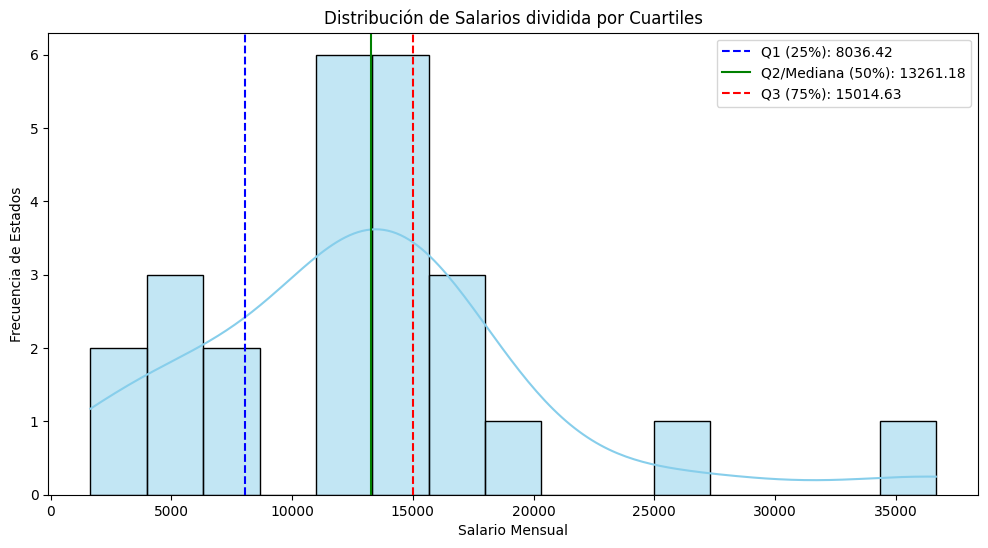

In [40]:
q1 = df['Salario'].quantile(0.25)
q2 = df['Salario'].quantile(0.50)
q3 = df['Salario'].quantile(0.75)

plt.figure(figsize=(12, 6))
sns.histplot(df['Salario'], kde=True, color='skyblue', bins=15)

plt.axvline(q1, color='blue', linestyle='--', label=f'Q1 (25%): {q1:.2f}')
plt.axvline(q2, color='green', linestyle='-', label=f'Q2/Mediana (50%): {q2:.2f}')
plt.axvline(q3, color='red', linestyle='--', label=f'Q3 (75%): {q3:.2f}')

plt.title('Distribución de Salarios dividida por Cuartiles')
plt.xlabel('Salario Mensual')
plt.ylabel('Frecuencia de Estados')
plt.legend()

plt.show()

In [19]:
#División de los 4 cuartiles
df_sorted = df.sort_values(by='Salario').reset_index(drop=True)
n = len(df_sorted)
indices = [0, int(n/4), int(n/2), int(3*n/4), n-1]

print("Cuartiles: ")
for i in range(4):
  print(f"Cuartil {i+1}: Elemento {indices[i]} (${df_sorted.loc[indices[i], 'Salario']:.2f}) "
          f"hasta elemento {indices[i+1]} (${df_sorted.loc[indices[i+1], 'Salario']:.2f})")

Cuartiles: 
Cuartil 1: Elemento 0 ($1643.54) hasta elemento 6 ($8036.42)
Cuartil 2: Elemento 6 ($8036.42) hasta elemento 12 ($13261.18)
Cuartil 3: Elemento 12 ($13261.18) hasta elemento 18 ($15014.63)
Cuartil 4: Elemento 18 ($15014.63) hasta elemento 24 ($36666.67)


**Tendencia central y promedio**


In [24]:
media = df['Salario'].mean()
desv_std = df['Salario'].std()
varianza = df['Salario'].var()

#Localizar el estado que este más cercano a la media
estado_media = df.loc[(df['Salario'] - media).abs().idxmin()]

print(f"Media: {media:.2f}")
print(f"Desviación estándar: {desv_std:.2f}")
print(f"Varianza: {varianza:.2f}")
print(f"El estado más cercano a la media es: {estado_media['Estado']} (${estado_media['Salario']:.2f})")

Media: 12983.44
Desviación estándar: 7403.97
Varianza: 54818767.96
El estado más cercano a la media es: Baja California ($13019.46)


Limites de control:

*   1 Sigma. $\mu - 1\sigma$$\mu + 1\sigma$
*   2 Sigma  $\mu - 2\sigma$$\mu + 2\sigma$
*   3 Sigma  $\mu - 3\sigma$$\mu + 3\sigma$

**Boxplot de control**

In [26]:

# Cálculo de los límites para 1, 2 y 3 sigmas
for k in [1, 2, 3]:
    lsc = media + (k * desv_std)
    lic = media - (k * desv_std)
    print(f"Límites a {k} Desviación(es) Estándar:")
    print(f"  ➢ Superior (LSC): ${lsc:,.2f}")
    print(f"  ➢ Inferior (LIC): ${lic:,.2f}\n")



Límites a 1 Desviación(es) Estándar:
  ➢ Superior (LSC): $20,387.41
  ➢ Inferior (LIC): $5,579.47

Límites a 2 Desviación(es) Estándar:
  ➢ Superior (LSC): $27,791.38
  ➢ Inferior (LIC): $-1,824.50

Límites a 3 Desviación(es) Estándar:
  ➢ Superior (LSC): $35,195.35
  ➢ Inferior (LIC): $-9,228.47



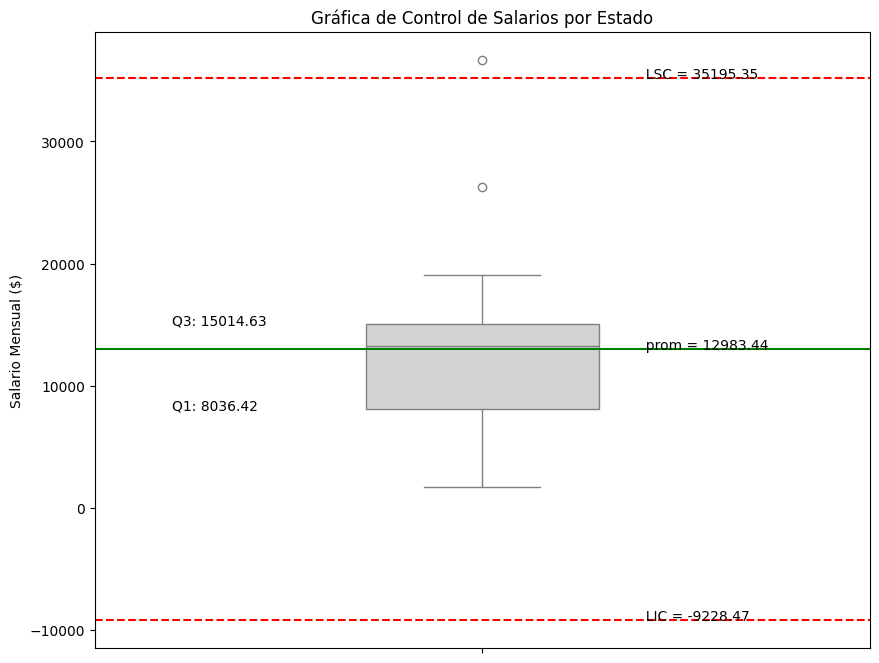

In [39]:
plt.figure(figsize=(10, 8))

sns.boxplot(y=df['Salario'], color='lightgray', width=0.3)

lsc = media + 3*desv_std
lic = media - 3*desv_std
q1 = df['Salario'].quantile(0.25) #cuartil 1
q3 = df['Salario'].quantile(0.75) #cuartil 3

# media
plt.axhline(media, color='green', label=f'Media: {media:.2f}')
plt.text(0.2, media, f'  prom = {media:.2f}')

# (LSC)
plt.axhline(lsc, color='red', linestyle='--', label=f'LSC: {lsc:.2f}')
plt.text(0.2, lsc, f'  LSC = {lsc:.2f}')

# (LIC)
plt.axhline(lic, color='red', linestyle='--', label=f'LIC: {lic:.2f}')
plt.text(0.2, lic, f'  LIC = {lic:.2f}')


plt.text(-0.4, q1, f'Q1: {q1:.2f}  ')
plt.text(-0.4, q3, f'Q3: {q3:.2f}  ')

plt.title("Gráfica de Control de Salarios por Estado")
plt.ylabel("Salario Mensual ($)")

plt.show()
